# 0. Environment Setup

In [7]:
import importlib
import subprocess
import sys

packages = {
    'yfinance': 'yfinance',
    'optuna': 'optuna',
    'xgboost': 'xgboost',
    'tensorflow': 'tensorflow',
    'sklearn': 'scikit-learn'
}

missing = []
for module, pip_name in packages.items():
    if importlib.util.find_spec(module) is None:
        missing.append(pip_name)

if missing:
    print(f'Installing: {", ".join(missing)}')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing, '--quiet'])
    print('Done.')
else:
    print('All packages already installed.')

All packages already installed.


In [8]:
import yfinance as yf
import pandas as pd
import numpy as np
import time, os, json

os.makedirs('data', exist_ok=True)
print('Setup complete')

Setup complete


In [9]:
TICKERS = [
    'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA',
    'META', 'NVDA', 'JPM',  'V',    'JNJ',
    'WMT',  'PG',   'MA',   'HD',   'BAC',
    'XOM',  'CVX',  'ABBV', 'PFE',  'KO',
    'PEP',  'MRK',  'CSCO', 'INTC', 'NFLX',
    'AMD',  'CRM',  'ORCL', 'ADBE', 'NKE',
    'DIS',  'CMCSA','VZ',   'T',    'MCD',
    'COST', 'IBM',  'GE',   'BA',   'CAT',
    'MMM',  'GS',   'AXP',  'HON',  'UNH',
]

TRAIN_START = '2015-01-01'
TRAIN_END   = '2024-12-31'
TEST_START  = '2025-01-01'
TEST_END    = '2025-12-31'

INTERVAL = '1wk'
N_STEPS  = 20   # 20 weeks (~5 months) of context for LSTM — more meaningful than 5

DATA_DIR = 'data'

print('Config set')

Config set


# Plan
1. Fetch Data from **Multiple Company**
3. Data Preparation — train/test split **before** scaling, RobustScaler (fit on train only), sequence generation per split
4. Build & Train LSTM — two LSTM layers with Dropout, EarlyStopping
5. Predict & Visualize
6. Evaluate — RMSE, MAE, R², Directional Accuracy, Information Coefficient

---
# 1. Fetching Stock Data

In [10]:
def download_and_pivot(tickers, start, end, interval):
    """Download OHLCV data from yfinance and return a long-format DataFrame."""
    raw = yf.download(tickers, start=start, end=end, interval=interval)

    # Flatten multi-index columns
    raw.columns = [f'{col[0]}_{col[1]}' if col[1] else col[0] for col in raw.columns]

    # Enforce numeric
    num_cols = [c for c in raw.columns if c.startswith(('Open_','High_','Low_','Close_','Volume_'))]
    raw[num_cols] = raw[num_cols].apply(pd.to_numeric, errors='coerce')

    # Wide -> long
    raw = raw.reset_index()
    melted = pd.melt(raw, id_vars=['Date'], value_vars=num_cols,
                     var_name='Type_Ticker', value_name='Value')
    split = melted['Type_Ticker'].str.rsplit('_', n=1, expand=True)
    melted[['Type', 'Ticker']] = split

    pivoted = melted.pivot_table(
        index=['Date', 'Ticker'], columns='Type', values='Value'
    ).reset_index()
    pivoted.columns.name = None

    # Basic cleaning
    pivoted = pivoted.drop_duplicates(subset=['Date', 'Ticker'], keep='last')
    pivoted = pivoted[pivoted['Volume'] >= 0]
    pivoted = pivoted.sort_values(['Ticker', 'Date']).reset_index(drop=True)

    return pivoted


def download_and_cache(tickers, start, end, interval, filename):
    """Load CSV from cache if params match, otherwise download and save."""
    csv_path = os.path.join(DATA_DIR, f'{filename}.csv')
    meta_path = os.path.join(DATA_DIR, f'{filename}_meta.json')

    current_meta = {
        'tickers': sorted(tickers),
        'start': start,
        'end': end,
        'interval': interval,
    }

    # Try loading from cache
    if os.path.exists(csv_path) and os.path.exists(meta_path):
        with open(meta_path, 'r') as f:
            saved_meta = json.load(f)
        if saved_meta == current_meta:
            print(f'Loading cached {filename} from {csv_path}')
            df = pd.read_csv(csv_path, parse_dates=['Date'])
            print(f'{filename}: {df.shape}')
            return df

    # Cache miss or param mismatch — download fresh
    print(f'Downloading {filename}...')
    df = download_and_pivot(tickers, start, end, interval)
    df.to_csv(csv_path, index=False)
    with open(meta_path, 'w') as f:
        json.dump(current_meta, f, indent=2)
    print(f'Saved to {csv_path}  ({df.shape})')
    return df


train_df = download_and_cache(TICKERS, TRAIN_START, TRAIN_END, INTERVAL, 'train_stock_data')
test_df  = download_and_cache(TICKERS, TEST_START,  TEST_END,  INTERVAL, 'test_stock_data')


Loading cached train_stock_data from data\train_stock_data.csv
train_stock_data: (23490, 8)
Loading cached test_stock_data from data\test_stock_data.csv
test_stock_data: (2340, 8)


In [11]:
train_df['Mid'] = (train_df['High'] + train_df['Low']) / 2.0
test_df['Mid']  = (test_df['High']  + test_df['Low'])  / 2.0

# Sort by Ticker and Date so diff/pct_change is computed in chronological order per company
train_df = train_df.sort_values(['Ticker', 'Date']).reset_index(drop=True)
test_df  = test_df.sort_values(['Ticker', 'Date']).reset_index(drop=True)

# Mid_diff = current Mid − previous Mid (within each Ticker group)
train_df['Mid_diff'] = train_df.groupby('Ticker')['Mid'].diff()
test_df['Mid_diff']  = test_df.groupby('Ticker')['Mid'].diff()

# Mid_pct = percentage return (scale-free, comparable across companies)
train_df['Mid_pct'] = train_df.groupby('Ticker')['Mid'].pct_change() * 100
test_df['Mid_pct']  = test_df.groupby('Ticker')['Mid'].pct_change() * 100

train_df.drop(columns=['Unnamed: 0'], inplace=True)
test_df.drop(columns=['Unnamed: 0'], inplace=True)

train_df = train_df.dropna(subset=['Mid_pct'])
test_df  = test_df.dropna(subset=['Mid_pct'])

# Mid_pct_next = next week's Mid_pct within each company
train_df['Mid_pct_next'] = train_df.groupby('Ticker')['Mid_pct'].shift(-1)
test_df['Mid_pct_next']  = test_df.groupby('Ticker')['Mid_pct'].shift(-1)

# Drop the last row per company (has NaN — no next week available)
train_df = train_df.dropna(subset=['Mid_pct_next'])
test_df  = test_df.dropna(subset=['Mid_pct_next'])

train_df.head()

,Date,Ticker,Close,High,Low,Open,Volume,Mid,Mid_diff,Mid_pct,Mid_pct_next
1,2015-01-08,AAPL,24.318993,25.083113,24.031062,24.192747,1.115053e+09,24.557088,0.629018,2.628788,-2.475776
2,2015-01-15,AAPL,24.263618,24.598059,23.300160,24.363286,9.480124e+08,23.949109,-0.607978,-2.475776,5.035609
3,2015-01-22,AAPL,25.539368,26.161740,24.148446,24.420872,1.591688e+09,25.155093,1.205984,5.035609,3.926943
4,2015-01-29,AAPL,26.480682,26.691094,25.594745,25.763073,1.411946e+09,26.142919,0.987826,3.926943,3.083794
5,2015-02-05,AAPL,27.658970,27.667829,26.230396,26.582556,1.041652e+09,26.949113,0.806194,3.083794,4.973989


---
# 2. Normality Check
Run three normality tests per feature and visualise with histograms + Q-Q plots.

C:\Users\hp\AppData\Local\Temp\ipykernel_7672\1568472340.py:36: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  ad = anderson(data, dist='norm')


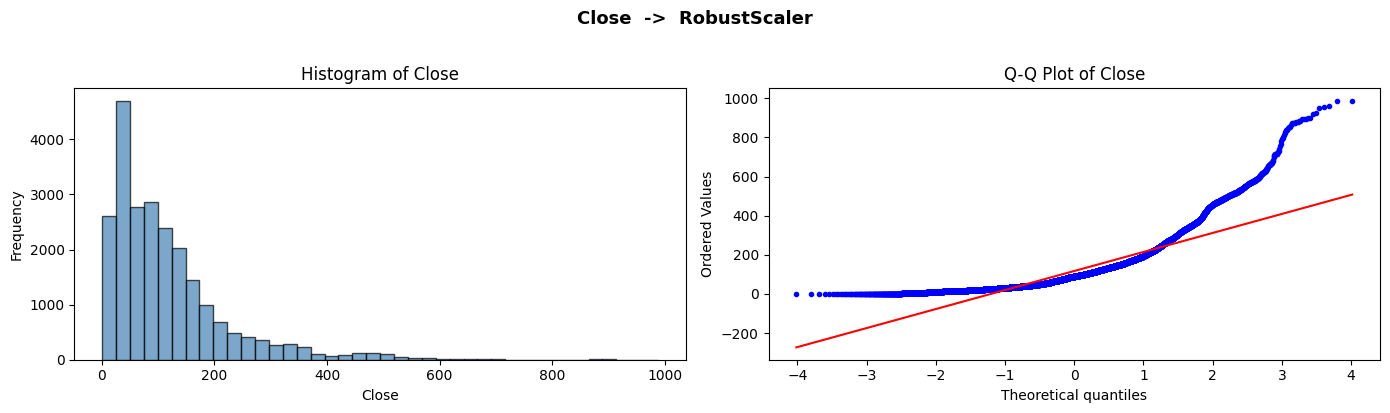

  Shapiro-Wilk     p = 5.1185e-61  NOT normal
  D'Agostino       p = 0.0000e+00  NOT normal
  Anderson-Darling   = 1173.3366  (crit 5% = 0.7520)  NOT normal
  -> Recommended scaler: RobustScaler
----------------------------------------------------------------------


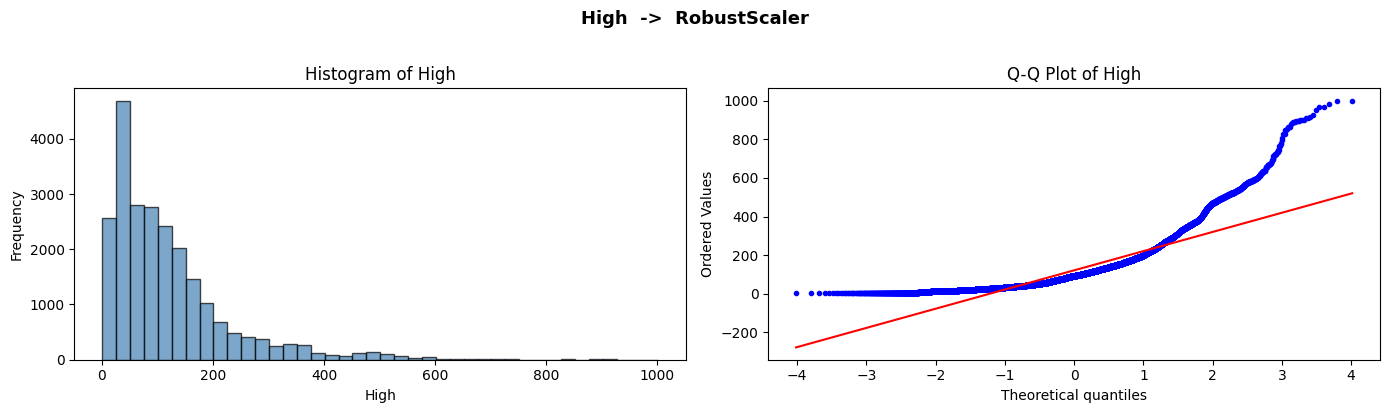

  Shapiro-Wilk     p = 1.8852e-62  NOT normal
  D'Agostino       p = 0.0000e+00  NOT normal
  Anderson-Darling   = 1178.2582  (crit 5% = 0.7520)  NOT normal
  -> Recommended scaler: RobustScaler
----------------------------------------------------------------------


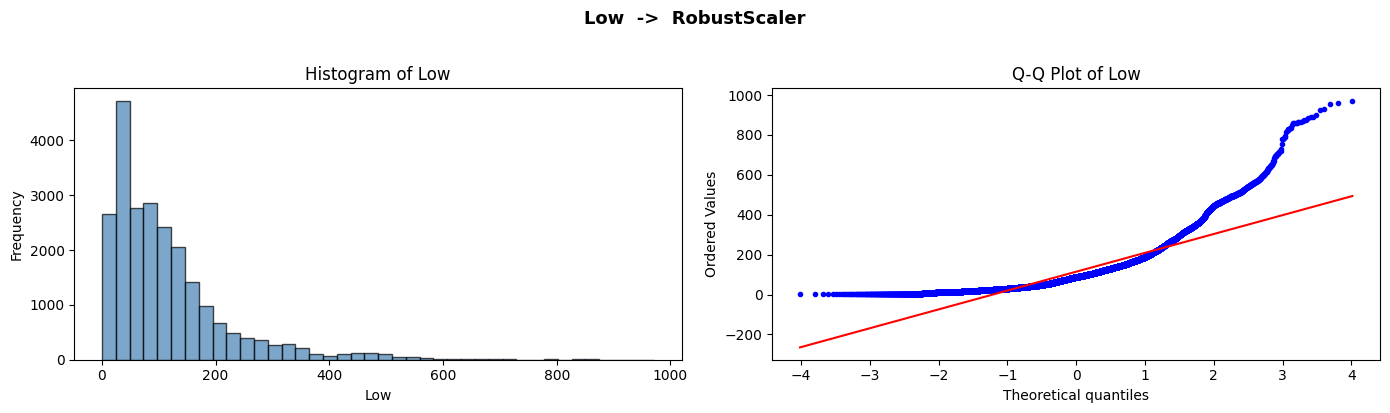

  Shapiro-Wilk     p = 2.2395e-63  NOT normal
  D'Agostino       p = 0.0000e+00  NOT normal
  Anderson-Darling   = 1166.1235  (crit 5% = 0.7520)  NOT normal
  -> Recommended scaler: RobustScaler
----------------------------------------------------------------------


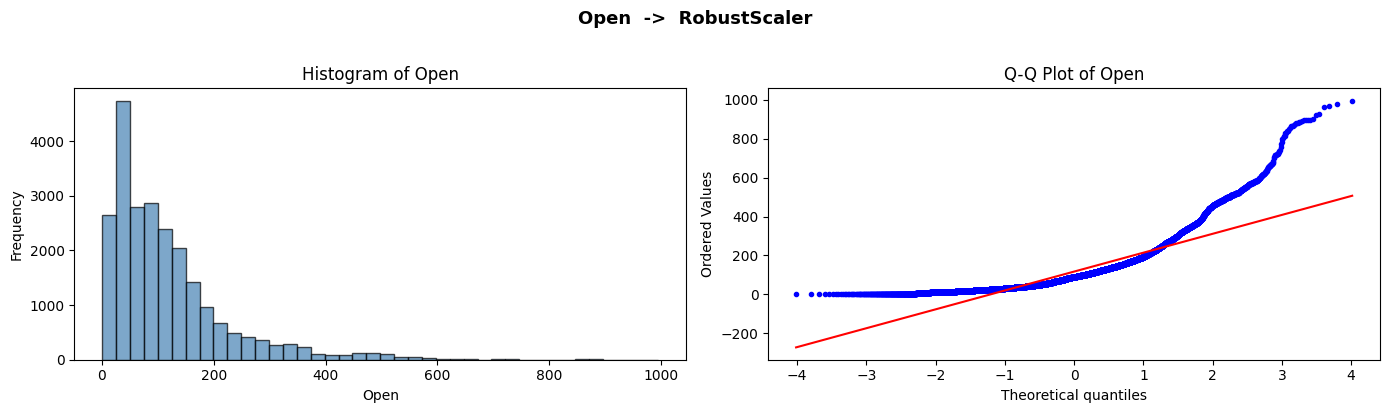

  Shapiro-Wilk     p = 3.0676e-62  NOT normal
  D'Agostino       p = 0.0000e+00  NOT normal
  Anderson-Darling   = 1172.4116  (crit 5% = 0.7520)  NOT normal
  -> Recommended scaler: RobustScaler
----------------------------------------------------------------------


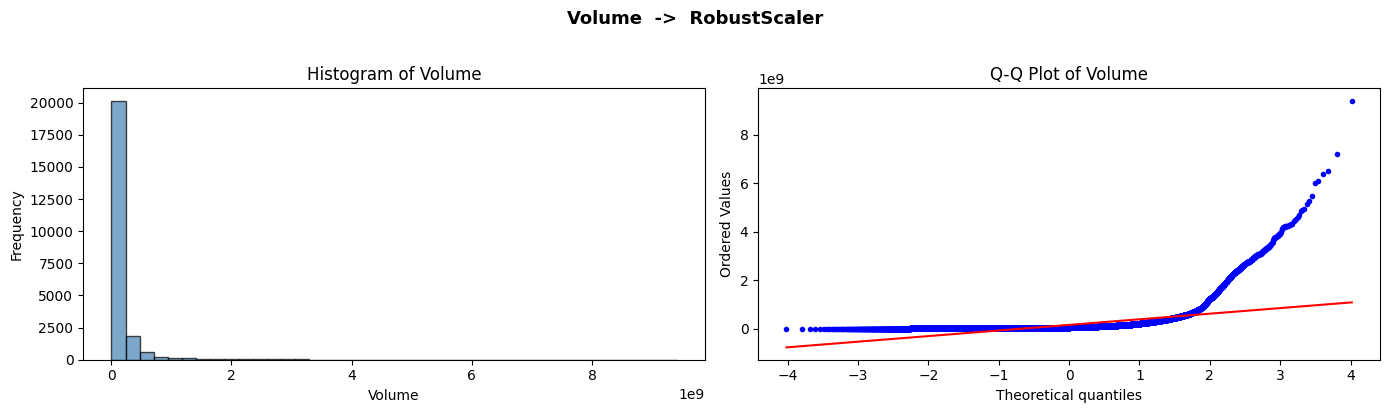

  Shapiro-Wilk     p = 3.8780e-86  NOT normal
  D'Agostino       p = 0.0000e+00  NOT normal
  Anderson-Darling   = 4645.2214  (crit 5% = 0.7520)  NOT normal
  -> Recommended scaler: RobustScaler
----------------------------------------------------------------------


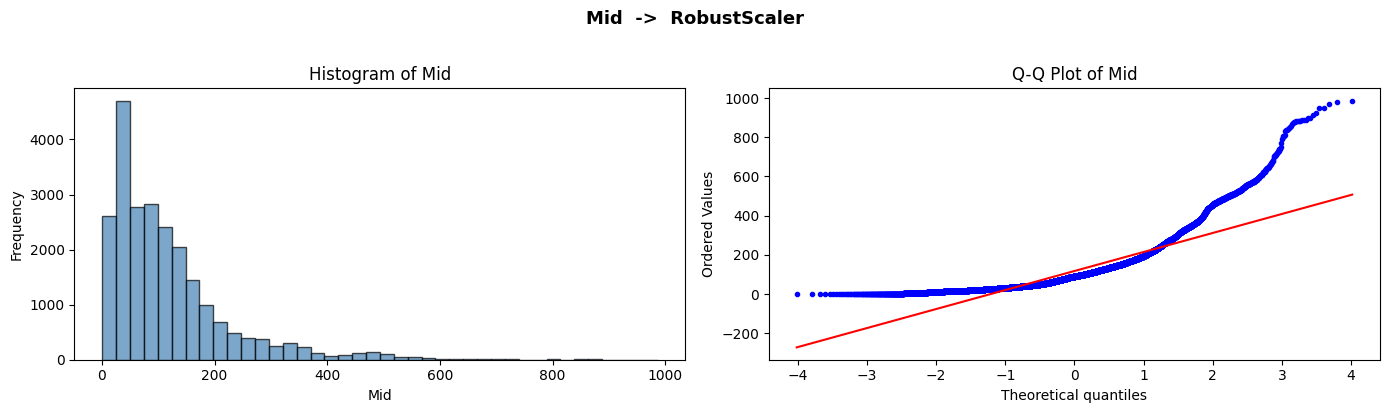

  Shapiro-Wilk     p = 8.0571e-63  NOT normal
  D'Agostino       p = 0.0000e+00  NOT normal
  Anderson-Darling   = 1171.6611  (crit 5% = 0.7520)  NOT normal
  -> Recommended scaler: RobustScaler
----------------------------------------------------------------------


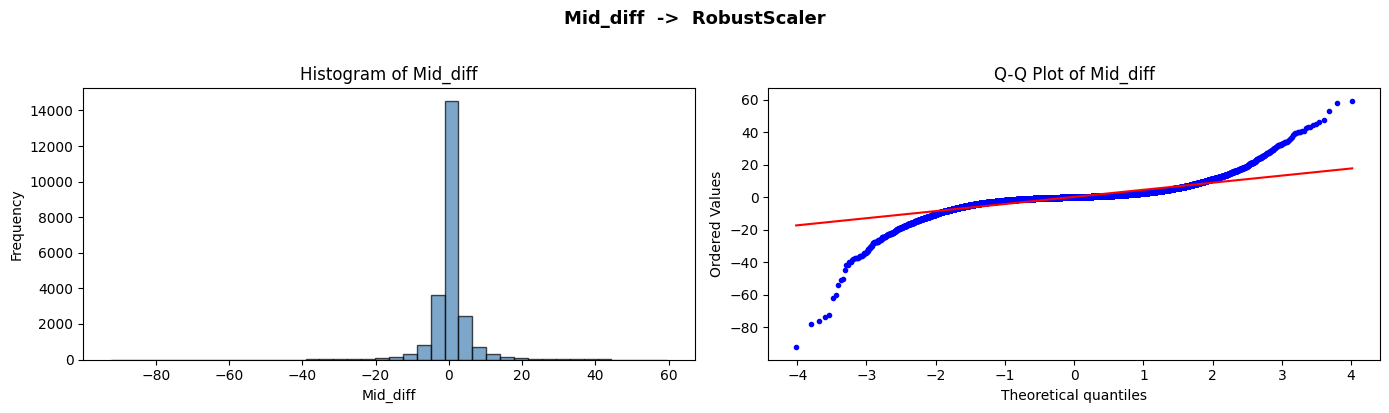

  Shapiro-Wilk     p = 2.5260e-66  NOT normal
  D'Agostino       p = 0.0000e+00  NOT normal
  Anderson-Darling   = 1629.8425  (crit 5% = 0.7520)  NOT normal
  -> Recommended scaler: RobustScaler
----------------------------------------------------------------------


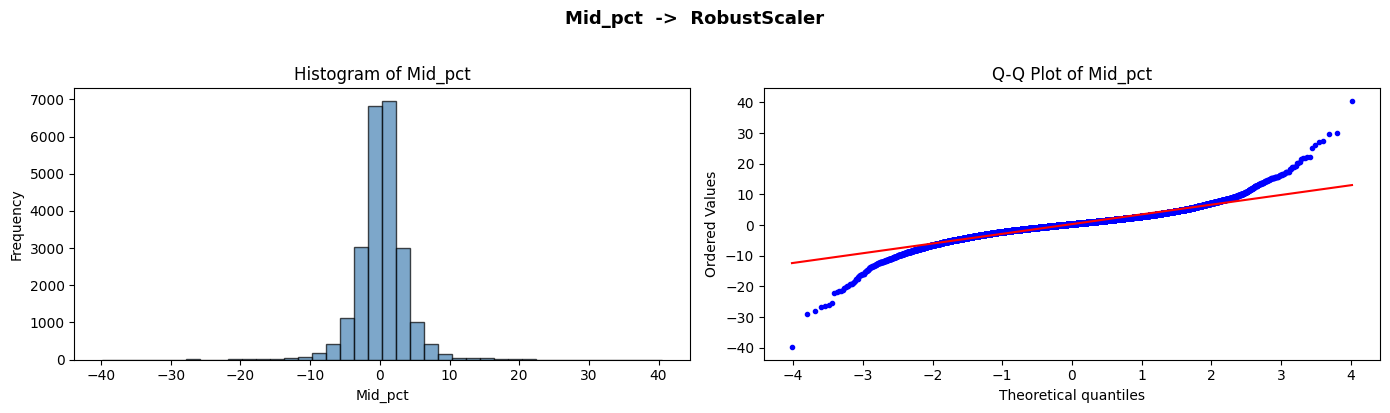

  Shapiro-Wilk     p = 4.8490e-42  NOT normal
  D'Agostino       p = 0.0000e+00  NOT normal
  Anderson-Darling   = 276.6858  (crit 5% = 0.7520)  NOT normal
  -> Recommended scaler: RobustScaler
----------------------------------------------------------------------


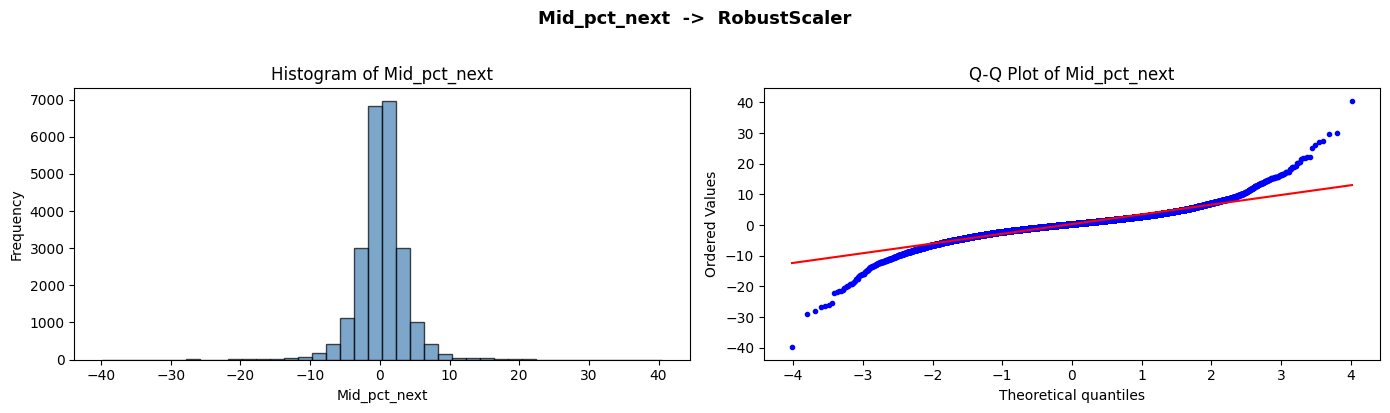

  Shapiro-Wilk     p = 1.7016e-48  NOT normal
  D'Agostino       p = 0.0000e+00  NOT normal
  Anderson-Darling   = 278.3732  (crit 5% = 0.7520)  NOT normal
  -> Recommended scaler: RobustScaler
----------------------------------------------------------------------

SUMMARY
     Feature  Shapiro p D'Agostino p Anderson stat AD critical 5%  Recommended
       Close 5.1185e-61   0.0000e+00     1173.3366         0.7520 RobustScaler
        High 1.8852e-62   0.0000e+00     1178.2582         0.7520 RobustScaler
         Low 2.2395e-63   0.0000e+00     1166.1235         0.7520 RobustScaler
        Open 3.0676e-62   0.0000e+00     1172.4116         0.7520 RobustScaler
      Volume 3.8780e-86   0.0000e+00     4645.2214         0.7520 RobustScaler
         Mid 8.0571e-63   0.0000e+00     1171.6611         0.7520 RobustScaler
    Mid_diff 2.5260e-66   0.0000e+00     1629.8425         0.7520 RobustScaler
     Mid_pct 4.8490e-42   0.0000e+00      276.6858         0.7520 RobustScaler
Mid_pct_next 1.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import shapiro, normaltest, anderson
from scipy import stats

SIGNIFICANCE = 0.05
SHAPIRO_MAX = 5000


def recommend_scaler(shapiro_p, dagostino_p, ad_normal):
    normal_votes = sum([shapiro_p > SIGNIFICANCE,
                        dagostino_p > SIGNIFICANCE,
                        ad_normal])
    if normal_votes >= 2:
        return "StandardScaler"
    return "RobustScaler"


summary_rows = []

for col in train_df.columns:
    if col in ('Ticker', 'Date'):
        continue
    data = train_df[col].values.astype(float)

    # Shapiro-Wilk (cap sample)
    shapiro_sample = (np.random.choice(data, SHAPIRO_MAX, replace=False)
                      if len(data) > SHAPIRO_MAX else data)
    _, shapiro_p = shapiro(shapiro_sample)

    # D'Agostino-Pearson
    _, dagostino_p = normaltest(data)

    # Anderson-Darling
    ad = anderson(data, dist='norm')
    ad_normal = ad.statistic < ad.critical_values[2]  # 5 % level

    scaler = recommend_scaler(shapiro_p, dagostino_p, ad_normal)
    summary_rows.append({'Feature': col,
                         'Shapiro p': f'{shapiro_p:.4e}',
                         "D'Agostino p": f'{dagostino_p:.4e}',
                         'Anderson stat': f'{ad.statistic:.4f}',
                         'AD critical 5%': f'{ad.critical_values[2]:.4f}',
                         'Recommended': scaler})

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].hist(data, bins=40, edgecolor='black', alpha=0.7, color='steelblue')
    axes[0].set_title(f'Histogram of {col}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frequency')

    stats.probplot(data, dist='norm', plot=axes[1])
    axes[1].set_title(f'Q-Q Plot of {col}')
    axes[1].get_lines()[0].set_markersize(3.0)

    plt.suptitle(f'{col}  ->  {scaler}', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    print(f'  Shapiro-Wilk     p = {shapiro_p:.4e}  {"normal" if shapiro_p > SIGNIFICANCE else "NOT normal"}')
    print(f"  D'Agostino       p = {dagostino_p:.4e}  {'normal' if dagostino_p > SIGNIFICANCE else 'NOT normal'}")
    print(f'  Anderson-Darling   = {ad.statistic:.4f}  (crit 5% = {ad.critical_values[2]:.4f})  {"normal" if ad_normal else "NOT normal"}')
    print(f'  -> Recommended scaler: {scaler}')
    print('-' * 70)

summary_df = pd.DataFrame(summary_rows)
print('\n' + '=' * 80)
print('SUMMARY')
print('=' * 80)
print(summary_df.to_string(index=False))

---
# 3. Data Preparation

## 3.1 Imports & Configuration

In [13]:
from sklearn.preprocessing import RobustScaler

LOOKBACK = 60
TRAIN_RATIO = 0.8

feature_cols = ['Open', 'High', 'Low', 'Close', 'Mid', 'Volume']
target_col = ['Mid_pct_next']

train_ticker_col = pd.get_dummies(train_df['Ticker'], prefix='ticker')
test_ticker_col = pd.get_dummies(test_df['Ticker'], prefix='ticker')

train_features_raw = pd.concat([train_df[feature_cols], train_ticker_col], axis=1)
test_features_raw = pd.concat([test_df[feature_cols], test_ticker_col], axis=1)

train_target_raw = train_df[target_col]
test_target_raw = test_df[target_col]

## 3.2 Feature Scaling — fit on train only

In [14]:
# Per-company scaling for features (prices differ across companies)
feature_scalers = {}
train_ohlcv_scaled = np.zeros((len(train_df), len(feature_cols)))
test_ohlcv_scaled  = np.zeros((len(test_df),  len(feature_cols)))

for ticker in train_df['Ticker'].unique():
    f_scaler = RobustScaler()
    train_mask = train_df['Ticker'] == ticker
    test_mask  = test_df['Ticker'] == ticker

    train_ohlcv_scaled[train_mask] = f_scaler.fit_transform(train_features_raw.loc[train_mask, feature_cols])
    test_ohlcv_scaled[test_mask]   = f_scaler.transform(test_features_raw.loc[test_mask, feature_cols])
    feature_scalers[ticker] = f_scaler

# Global scaling for target (Mid_pct is already comparable across companies)
target_scaler = RobustScaler()
train_target_scaled = target_scaler.fit_transform(train_target_raw)
test_target_scaled  = target_scaler.transform(test_target_raw)

# Recombine: scaled OHLCV + original ticker dummies
train_features = np.hstack([train_ohlcv_scaled, train_ticker_col.values])
test_features  = np.hstack([test_ohlcv_scaled,  test_ticker_col.values])
train_target = train_target_scaled
test_target  = test_target_scaled

print(f'Train features shape: {train_features.shape}')
print(f'Train target shape  : {train_target.shape}')

Train features shape: (23400, 51)
Train target shape  : (23400, 1)


## 3.4 Sequence Generation
Pad the test input with the last `LOOKBACK` rows from training so the first test sequence uses only train-era data.

In [15]:
def create_sequences_per_company(df, features, target, lookback):
    X, y = [], []
    for _, group_idx in df.groupby('Ticker').groups.items():
        idx = group_idx.values
        for i in range(lookback, len(idx)):
            X.append(features[idx[i - lookback:i]])
            y.append(target[idx[i], 0])
    return np.array(X), np.array(y)


# Training sequences — train_df index aligns with train_features/train_target rows
def create_sequences_per_company(df, features, target, lookback):
    df = df.reset_index(drop=True)
    X, y = [], []
    for ticker, group in df.groupby('Ticker'):
        pos = group.index.to_numpy()          # 0-based positions aligned with features/target
        for i in range(lookback, len(pos)):
            idx_win = pos[i-lookback:i]
            X.append(features[idx_win])
            y.append(target[pos[i], 0])
    return np.array(X), np.array(y)

# ensure alignment
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

X_train, y_train = create_sequences_per_company(train_df, train_features, train_target, LOOKBACK)

# Test sequences — concat last LOOKBACK train rows per company before test rows
test_dfs_padded, test_features_list, test_target_list = [], [], []
for ticker, group in train_df.groupby('Ticker'):
    idx = group.index.to_numpy()
    test_mask = test_df['Ticker'] == ticker
    n_test = test_mask.sum()
    if n_test == 0:
        continue
    test_idx = test_df.index[test_mask].to_numpy()

    test_features_list.append(train_features[idx[-LOOKBACK:]])
    test_features_list.append(test_features[test_idx])

    test_target_list.append(train_target[idx[-LOOKBACK:]])
    test_target_list.append(test_target[test_idx])

    test_dfs_padded.append(pd.concat([
        train_df.iloc[idx[-LOOKBACK:]],
        test_df.loc[test_mask]
    ], ignore_index=True))

test_df_padded = pd.concat(test_dfs_padded, ignore_index=True)
test_features_padded = np.vstack(test_features_list)
test_target_padded = np.vstack(test_target_list)

X_test, y_test = create_sequences_per_company(
    test_df_padded, test_features_padded, test_target_padded, LOOKBACK
)

print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_test : {X_test.shape}  y_test : {y_test.shape}')


X_train: (20700, 60, 51)  y_train: (20700,)
X_test : (2250, 60, 51)  y_test : (2250,)


---
# 4. Building and Training LSTM

In [16]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Input, Bidirectional
from keras.callbacks import EarlyStopping

model = Sequential([
    Input(shape=(LOOKBACK, X_train.shape[2])),
    Bidirectional(LSTM(100, return_sequences=True)),
    Dropout(0.2),
    Bidirectional(LSTM(100, return_sequences=False)),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 60, 200)        │       121,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 200)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 200)            │       240,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           201 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 362,601 (1.38 MB)

 Trainable params: 362,601 (1.38 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
583/583 ━━━━━━━━━━━━━━━━━━━━ 169s 290ms/step - loss: 1.0866 - mae: 0.7249 - val_loss: 0.6018 - val_mae: 0.5717
Epoch 2/100
583/583 ━━━━━━━━━━━━━━━━━━━━ 125s 214ms/step - loss: 1.0829 - mae: 0.7228 - val_loss: 0.5815 - val_mae: 0.5559
Epoch 3/100
583/583 ━━━━━━━━━━━━━━━━━━━━ 121s 207ms/step - loss: 1.0764 - mae: 0.7214 - val_loss: 0.5819 - val_mae: 0.5556
Epoch 4/100
583/583 ━━━━━━━━━━━━━━━━━━━━ 138s 200ms/step - loss: 1.0777 - mae: 0.7215 - val_loss: 0.5846 - val_mae: 0.5576
Epoch 5/100
583/583 ━━━━━━━━━━━━━━━━━━━━ 142s 200ms/step - loss: 1.0720 - mae: 0.7195 - val_loss: 0.5889 - val_mae: 0.5584
Epoch 6/100
583/583 ━━━━━━━━━━━━━━━━━━━━ 87s 150ms/step - loss: 1.0686 - mae: 0.7198 - val_loss: 0.5868 - val_mae: 0.5569
Epoch 7/100
583/583 ━━━━━━━━━━━━━━━━━━━━ 79s 135ms/step - loss: 1.0658 - mae: 0.7180 - val_loss: 0.5967 - val_mae: 0.5634
Epoch 8/100
583/583 ━━━━━━━━━━━━━━━━━━━━ 93s 160ms/step - loss: 1.0631 - mae: 0.7171 - val_loss: 0.5885 - val_mae: 0.5611
Epoch 9/100
583/583

KeyboardInterrupt: 

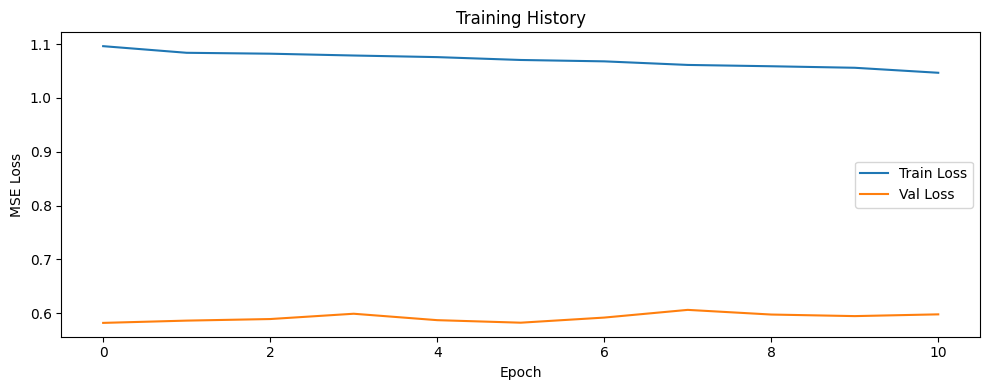

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training History')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

---
# 5. Making Predictions

In [ ]:
pred_scaled = model.predict(X_test)

# Track which test samples belong to which company
test_company_labels = []
for ticker, group_idx in test_df_padded.groupby('Ticker').groups.items():
    idx = group_idx.values
    for i in range(LOOKBACK, len(idx)):
        test_company_labels.append(ticker)
test_company_labels = np.array(test_company_labels)

# Inverse-transform using the global target_scaler
prediction = target_scaler.inverse_transform(pred_scaled)
y_test_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1))

print(f'Predictions shape: {prediction.shape}')
print(f'Actuals shape     : {y_test_actual.shape}')

71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step
Predictions shape: (2250, 1)
Actuals shape     : (2250, 1)


---
# 6. Visualisation

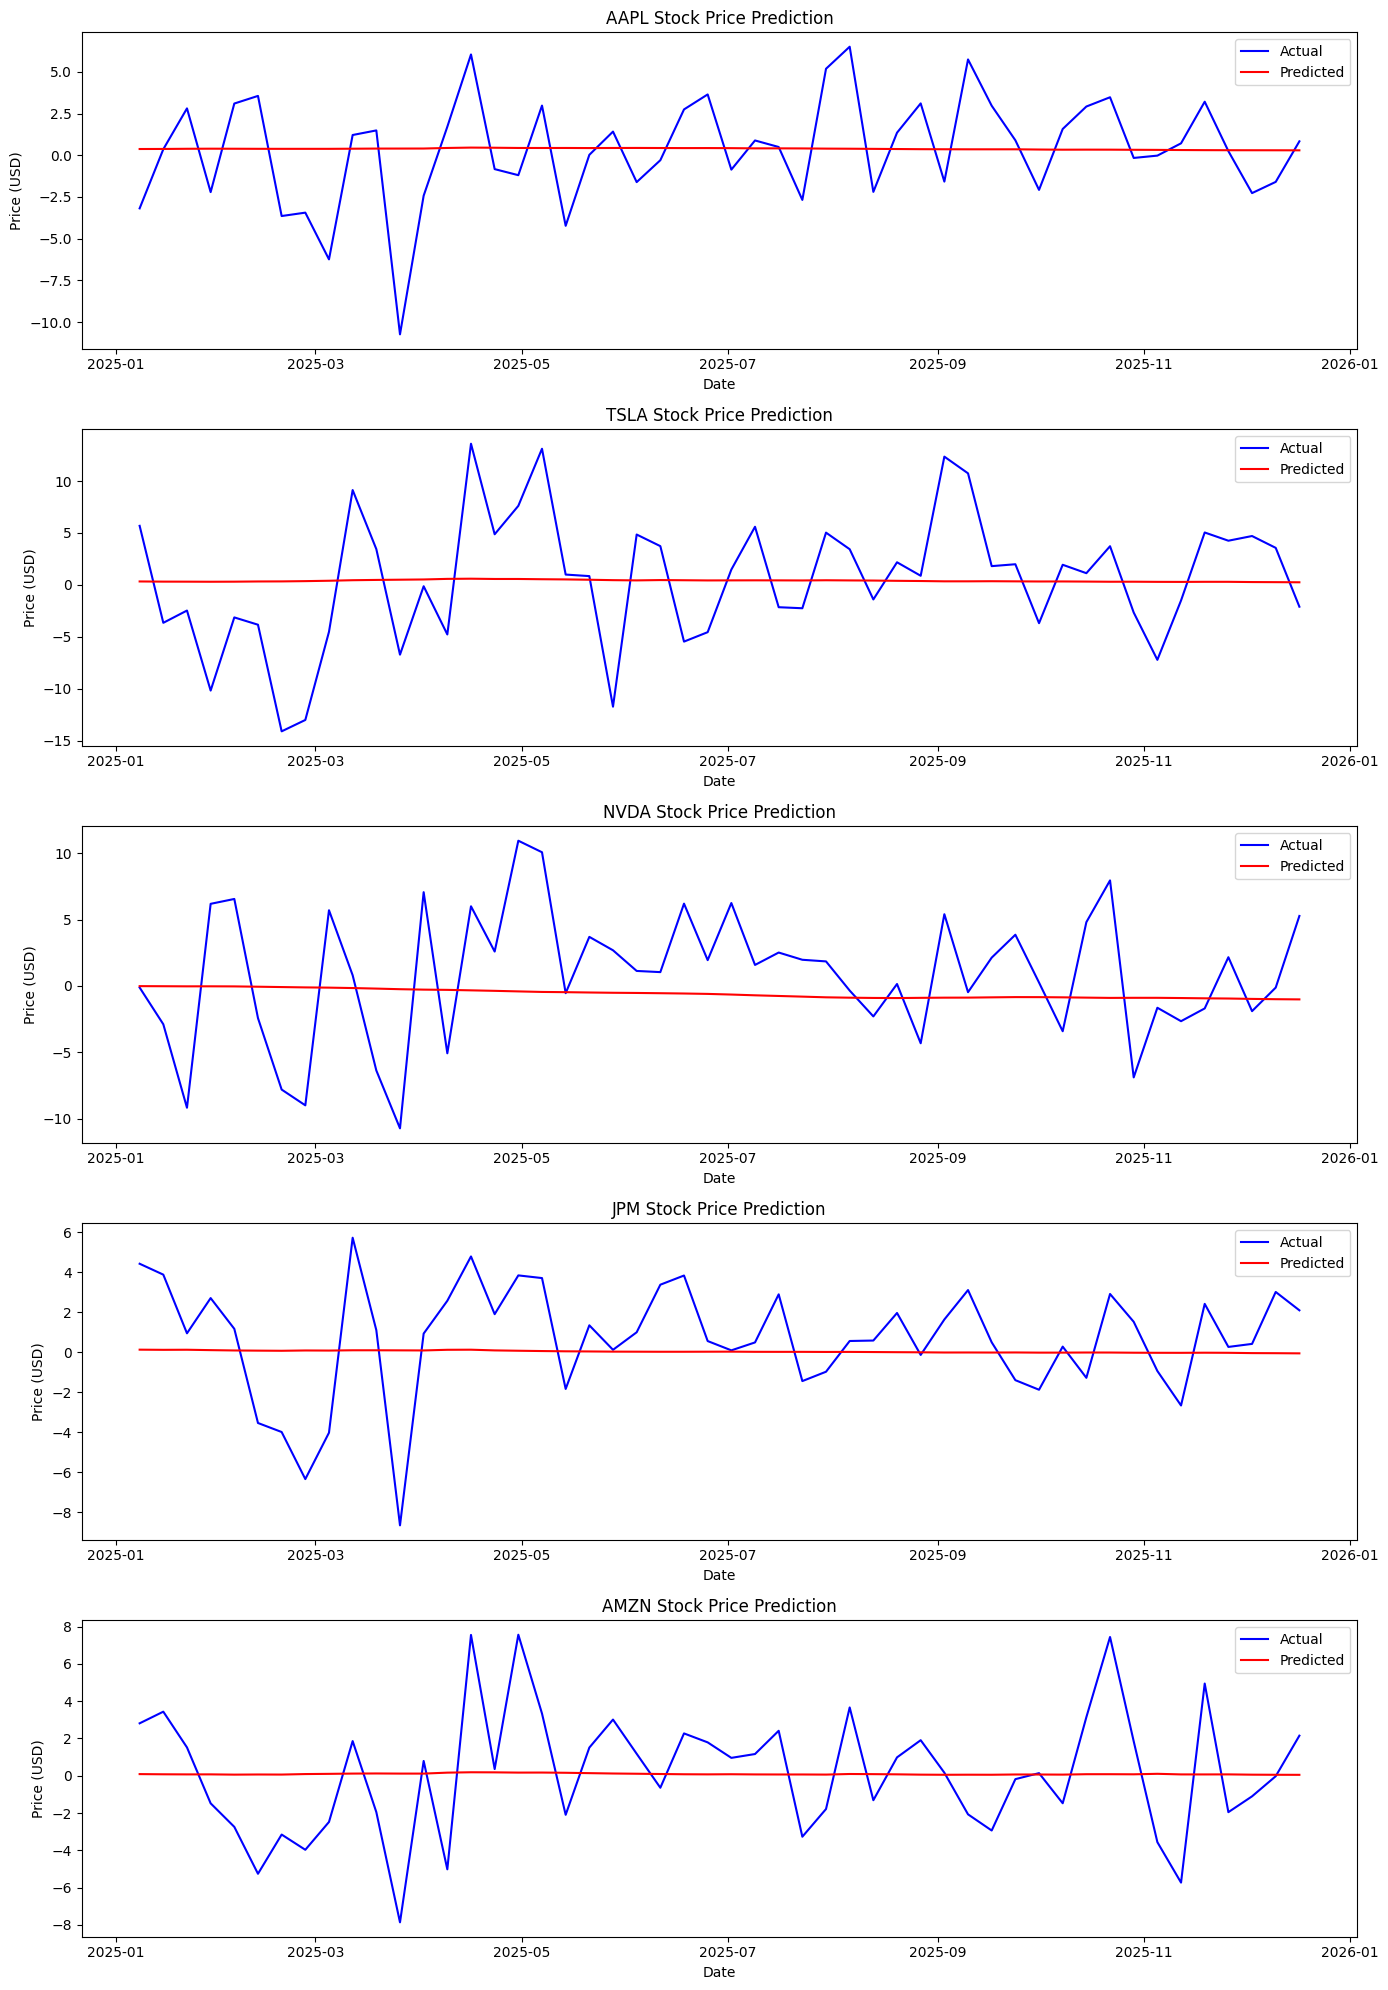

In [ ]:
selected_tickers = ['AAPL', 'TSLA', 'NVDA', 'JPM', 'AMZN']
fig, axes = plt.subplots(len(selected_tickers), 1, figsize=(14, 4 * len(selected_tickers)))

for ax, ticker in zip(axes, selected_tickers):
    mask = test_company_labels == ticker
    dates = test_df[test_df['Ticker'] == ticker]['Date'].values
    ax.plot(dates, y_test_actual[mask], label='Actual', color='blue')
    ax.plot(dates, prediction[mask], label='Predicted', color='red')
    ax.set_title(f'{ticker} Stock Price Prediction')
    ax.set_xlabel('Date')
    ax.set_ylabel('Price (USD)')
    ax.legend()

plt.tight_layout()
plt.show()

---
# 7. Model Evaluation

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def directional_accuracy(y_true, y_pred):
    """Percentage of samples where predicted sign matches actual sign."""
    return np.mean(np.sign(y_true) == np.sign(y_pred)) * 100

def information_coefficient(y_true, y_pred):
    """Pearson correlation between predicted and actual values."""
    return np.corrcoef(y_true.flatten(), y_pred.flatten())[0, 1]

# Overall metrics
mse  = mean_squared_error(y_test_actual, prediction)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test_actual, prediction)
r2   = r2_score(y_test_actual, prediction)
da   = directional_accuracy(y_test_actual, prediction)
ic   = information_coefficient(y_test_actual, prediction)

print('=' * 60)
print('LSTM Multi-Company — Overall Test Metrics (Mid_pct %)')
print('=' * 60)

print(f'  MSE                  : {mse:.4f}')
print(f'  RMSE                 : {rmse:.4f} %')
print(f'  MAE                  : {mae:.4f} %')
print(f'  R²                   : {r2:.4f}')
print(f'  Directional Accuracy : {da:.2f}%  (baseline = 50%)')
print(f'  Information Coeff.   : {ic:.4f}  (random ≈ 0)')
print('=' * 60)

# Per-company breakdown
print('\nPer-Company Metrics:')
print(f'{"Ticker":<8} {"RMSE":>8} {"MAE":>8} {"R²":>8} {"DA%":>8} {"IC":>8}')
print('-' * 54)
for ticker in sorted(np.unique(test_company_labels)):
    mask = test_company_labels == ticker
    yt = y_test_actual[mask]
    yp = prediction[mask]
    t_rmse = np.sqrt(mean_squared_error(yt, yp))
    t_mae  = mean_absolute_error(yt, yp)
    t_r2   = r2_score(yt, yp)
    t_da   = directional_accuracy(yt, yp)
    t_ic   = information_coefficient(yt, yp)
    print(f'{ticker:<8} {t_rmse:>8.4f} {t_mae:>8.4f} {t_r2:>8.4f} {t_da:>7.2f}% {t_ic:>8.4f}')

LSTM Multi-Company — Overall Test Metrics (Mid_pct %)
  MSE                  : 13.5279
  RMSE                 : 3.6780 %
  MAE                  : 2.6408 %
  R²                   : -0.0172
  Directional Accuracy : 48.44%  (baseline = 50%)
  Information Coeff.   : 0.0068  (random ≈ 0)

Per-Company Metrics:
Ticker       RMSE      MAE       R²      DA%       IC
------------------------------------------------------
AAPL       3.1888   2.4543  -0.0007   58.00%  -0.0162
ABBV       3.0740   2.3323  -0.0519   42.00%   0.1203
ADBE       3.1381   2.6409  -0.0172   48.00%   0.2011
AMD        6.5614   4.9383  -0.0376   52.00%   0.0961
AMZN       3.2838   2.6253   0.0042   54.00%   0.2115
AXP        3.1739   2.5300  -0.0368   40.00%  -0.0548
BA         4.5466   3.5248   0.0029   66.00%   0.3611
BAC        3.1855   2.4612  -0.0252   44.00%   0.0687
CAT        3.9948   3.2188  -0.1362   40.00%  -0.1079
CMCSA      2.6341   2.0973  -0.0210   40.00%   0.2122
COST       2.4199   1.8491   0.0075   48.00% 

## 8. Visualization

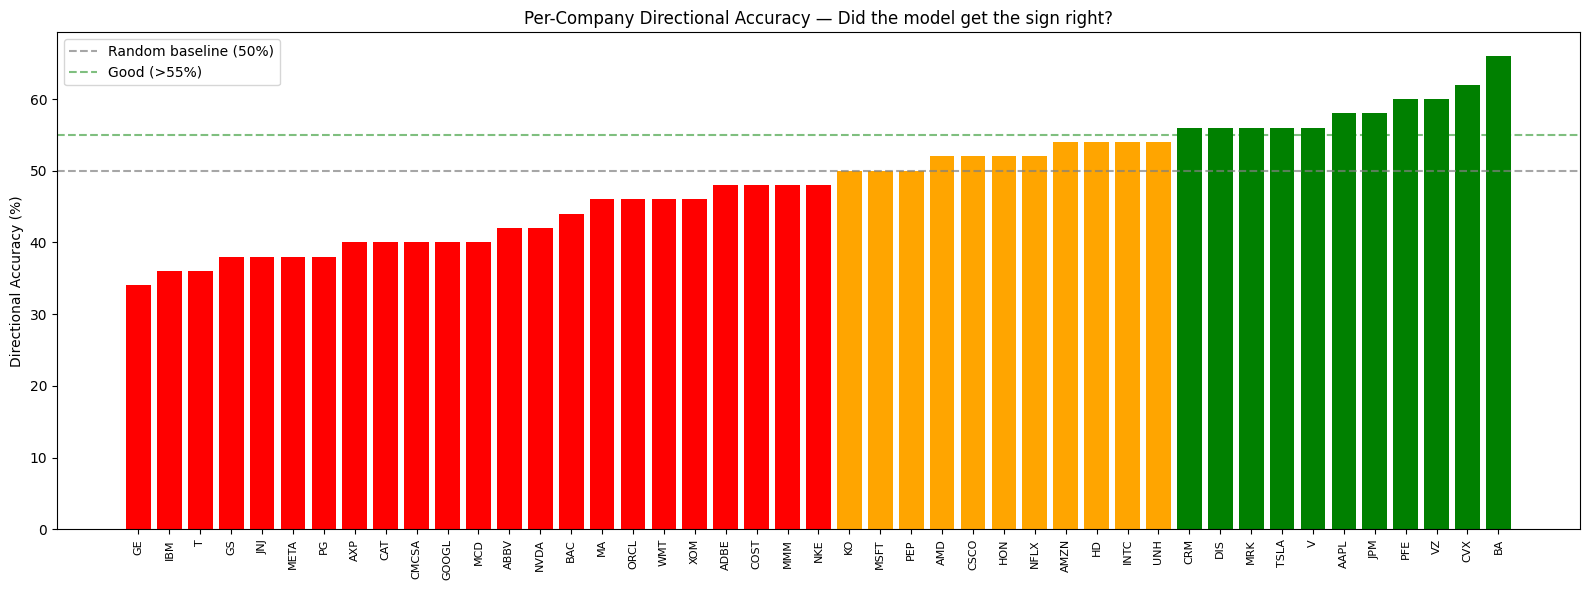

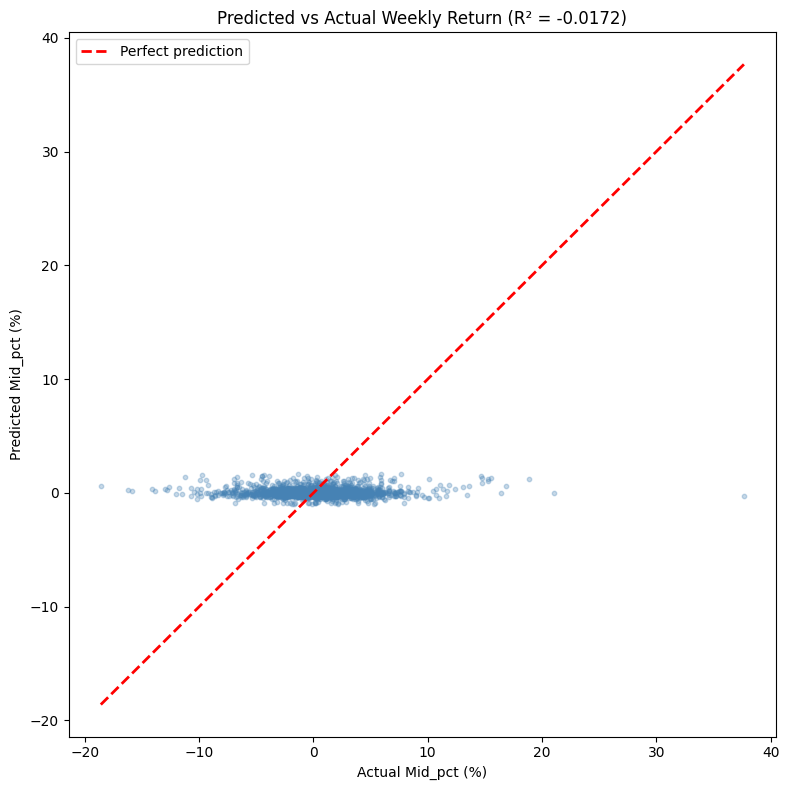

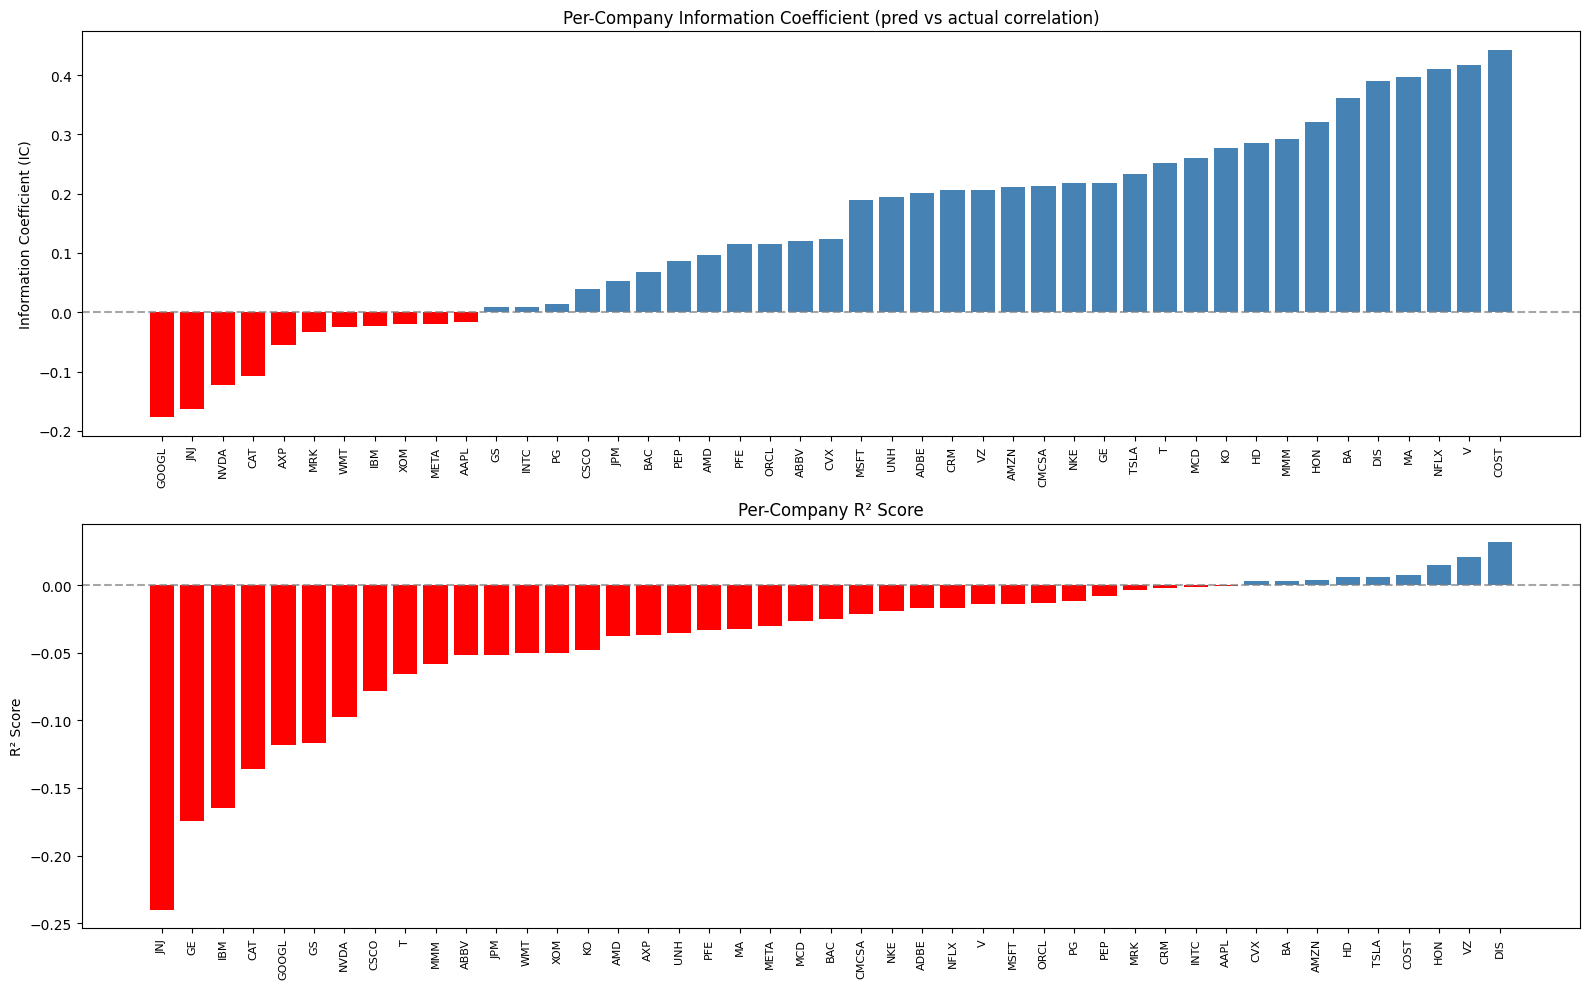

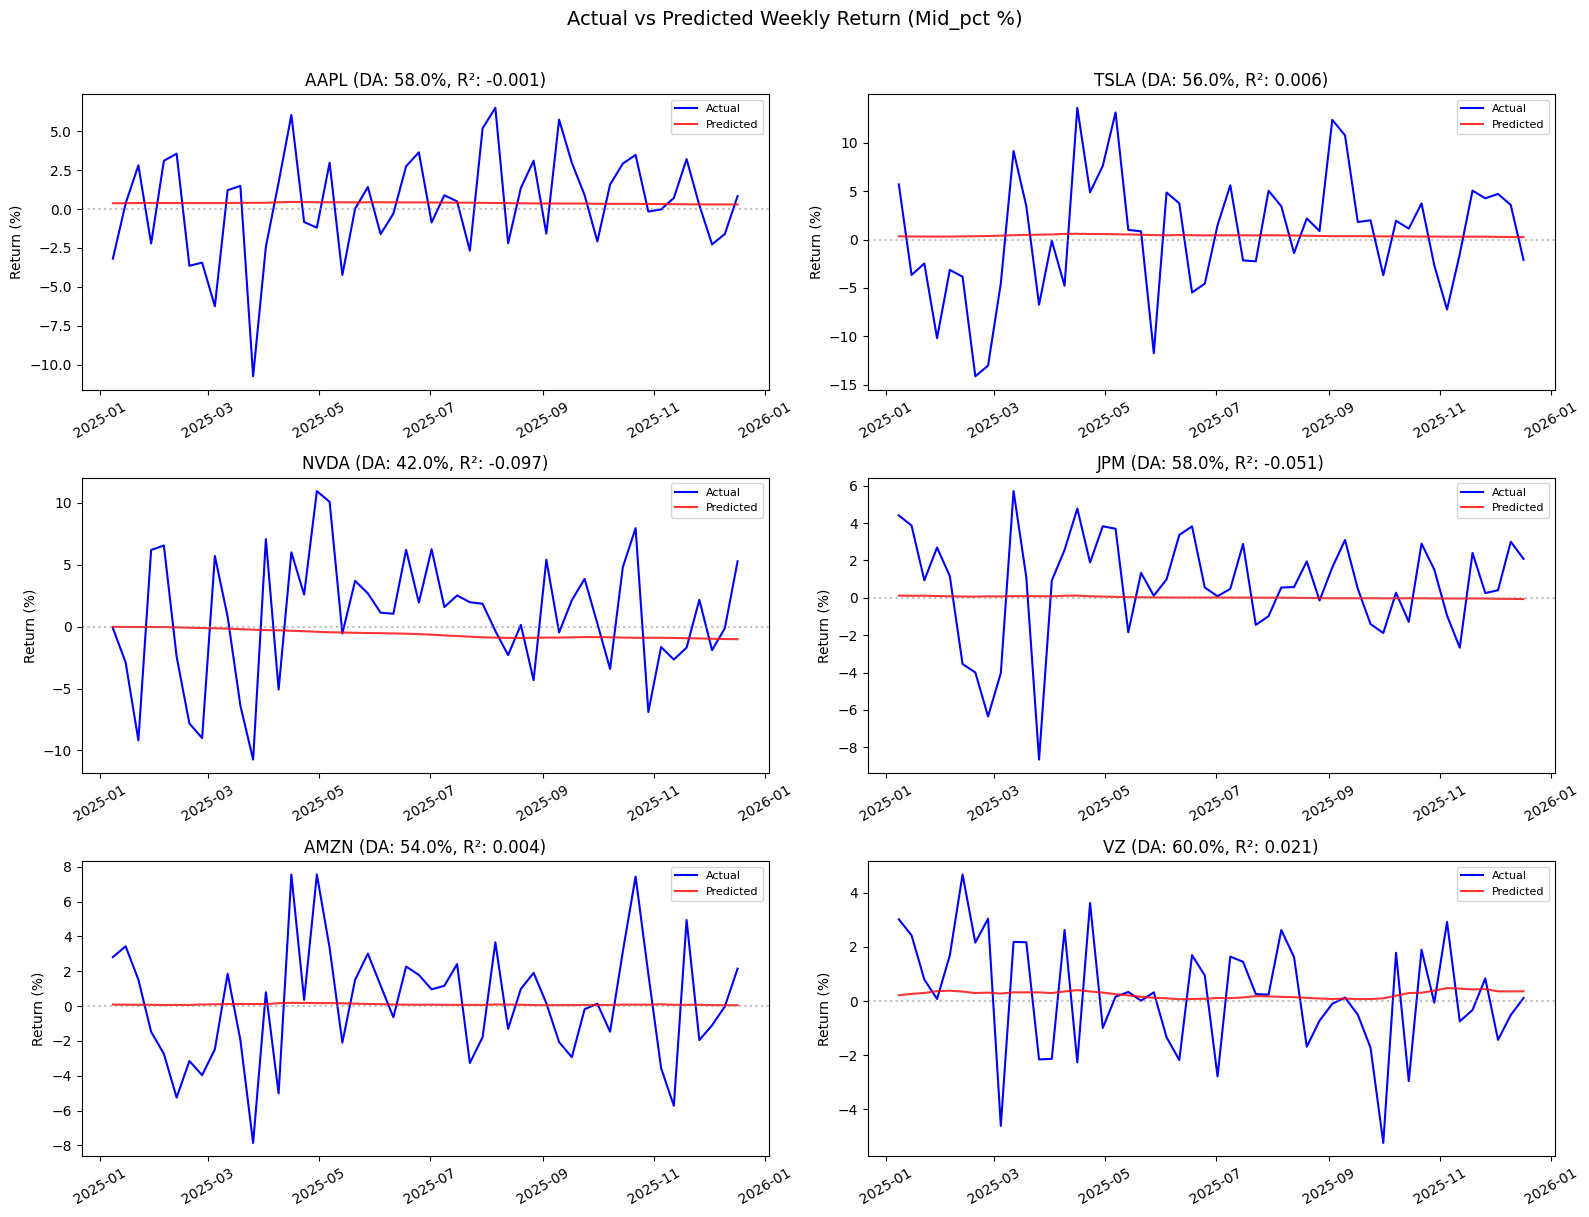

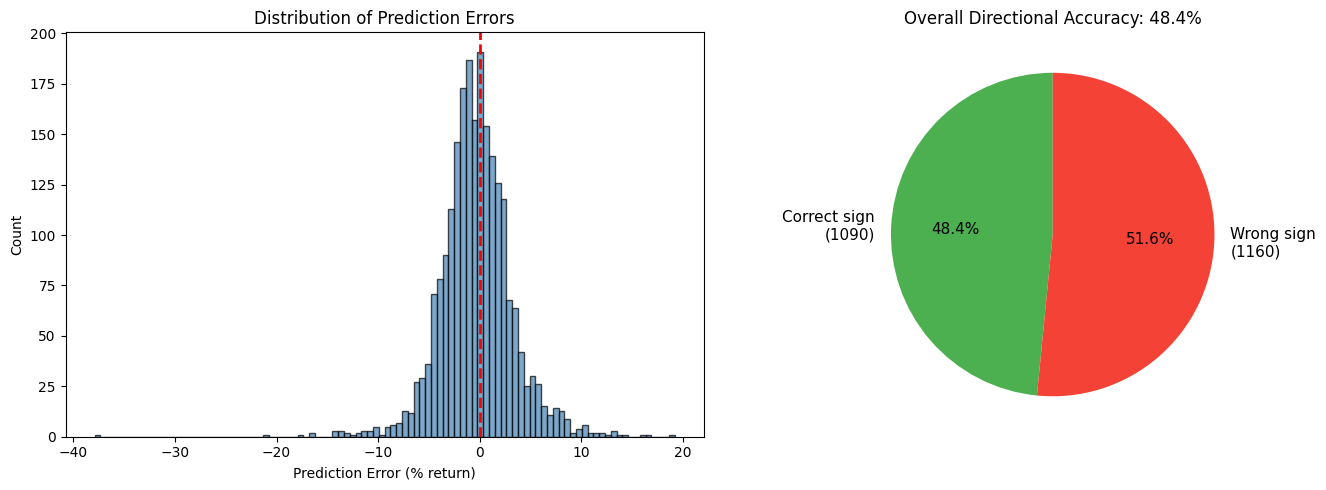

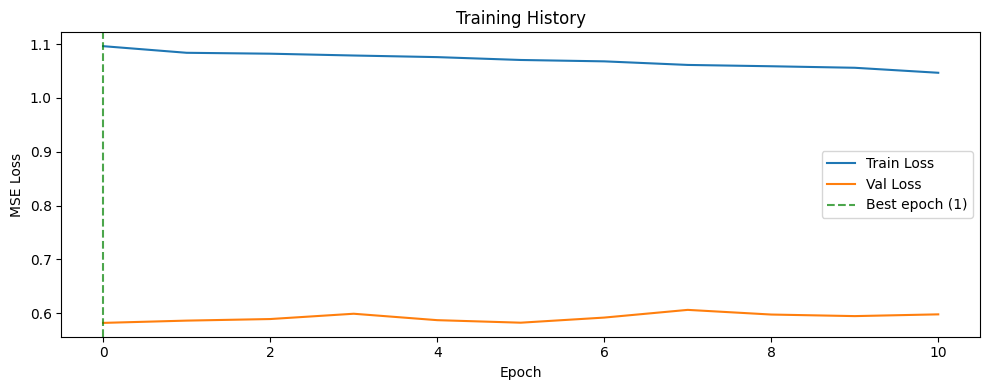

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def directional_accuracy(y_true, y_pred):
    return np.mean(np.sign(y_true) == np.sign(y_pred)) * 100

def information_coefficient(y_true, y_pred):
    return np.corrcoef(y_true.flatten(), y_pred.flatten())[0, 1]

company_metrics = {}
for ticker in sorted(np.unique(test_company_labels)):
    mask = test_company_labels == ticker
    yt = y_test_actual[mask]
    yp = prediction[mask]
    company_metrics[ticker] = {
        'DA': directional_accuracy(yt, yp),
        'IC': information_coefficient(yt, yp),
        'R2': r2_score(yt, yp),
        'MAE': mean_absolute_error(yt, yp),
        'RMSE': np.sqrt(mean_squared_error(yt, yp)),
    }

# --- 8a. Per-Company Directional Accuracy Bar Chart ---
tickers_sorted = sorted(company_metrics, key=lambda t: company_metrics[t]['DA'])
das = [company_metrics[t]['DA'] for t in tickers_sorted]
colors = ['red' if d < 50 else 'orange' if d < 55 else 'green' for d in das]

plt.figure(figsize=(16, 6))
plt.bar(range(len(tickers_sorted)), das, color=colors)
plt.xticks(range(len(tickers_sorted)), tickers_sorted, rotation=90, fontsize=8)
plt.axhline(y=50, color='gray', linestyle='--', alpha=0.7, label='Random baseline (50%)')
plt.axhline(y=55, color='green', linestyle='--', alpha=0.5, label='Good (>55%)')
plt.ylabel('Directional Accuracy (%)')
plt.title('Per-Company Directional Accuracy — Did the model get the sign right?')
plt.legend()
plt.tight_layout()
plt.show()

# --- 8b. Predicted vs Actual Scatter Plot ---
plt.figure(figsize=(8, 8))
plt.scatter(y_test_actual, prediction, alpha=0.3, s=10, color='steelblue')
min_val = min(y_test_actual.min(), prediction.min())
max_val = max(y_test_actual.max(), prediction.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual Mid_pct (%)')
plt.ylabel('Predicted Mid_pct (%)')
overall_r2 = r2_score(y_test_actual, prediction)
plt.title(f'Predicted vs Actual Weekly Return (R² = {overall_r2:.4f})')
plt.legend()
plt.tight_layout()
plt.show()

# --- 8c. IC bar chart + line plots for selected stocks ---
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Top: IC bar chart
tickers_by_ic = sorted(company_metrics, key=lambda t: company_metrics[t]['IC'])
ics = [company_metrics[t]['IC'] for t in tickers_by_ic]
ic_colors = ['red' if v < 0 else 'steelblue' for v in ics]
axes[0].bar(range(len(tickers_by_ic)), ics, color=ic_colors)
axes[0].set_xticks(range(len(tickers_by_ic)))
axes[0].set_xticklabels(tickers_by_ic, rotation=90, fontsize=8)
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.7)
axes[0].set_ylabel('Information Coefficient (IC)')
axes[0].set_title('Per-Company Information Coefficient (pred vs actual correlation)')

# Bottom: R² bar chart
tickers_by_r2 = sorted(company_metrics, key=lambda t: company_metrics[t]['R2'])
r2s = [company_metrics[t]['R2'] for t in tickers_by_r2]
r2_colors = ['red' if v < 0 else 'steelblue' for v in r2s]
axes[1].bar(range(len(tickers_by_r2)), r2s, color=r2_colors)
axes[1].set_xticks(range(len(tickers_by_r2)))
axes[1].set_xticklabels(tickers_by_r2, rotation=90, fontsize=8)
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.7)
axes[1].set_ylabel('R² Score')
axes[1].set_title('Per-Company R² Score')

plt.tight_layout()
plt.show()

# --- 8d. Line plots for 6 selected stocks ---
selected = ['AAPL', 'TSLA', 'NVDA', 'JPM', 'AMZN', 'VZ']
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

for ax, ticker in zip(axes.flatten(), selected):
    mask = test_company_labels == ticker
    dates = test_df[test_df['Ticker'] == ticker]['Date'].values
    ax.plot(dates, y_test_actual[mask], label='Actual', color='blue', linewidth=1.5)
    ax.plot(dates, prediction[mask], label='Predicted', color='red', linewidth=1.5, alpha=0.8)
    t_da = company_metrics[ticker]['DA']
    t_r2 = company_metrics[ticker]['R2']
    ax.set_title(f'{ticker} (DA: {t_da:.1f}%, R²: {t_r2:.3f})')
    ax.set_ylabel('Return (%)')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=30)
    ax.axhline(y=0, color='gray', linestyle=':', alpha=0.5)

plt.suptitle('Actual vs Predicted Weekly Return (Mid_pct %)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# --- 8e. Prediction Error Distribution ---
errors = (prediction - y_test_actual).flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(errors, bins=100, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Prediction Error (% return)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Prediction Errors')

# Directional accuracy pie chart
correct = np.sum(np.sign(y_test_actual.flatten()) == np.sign(prediction.flatten()))
wrong = len(y_test_actual) - correct
da_overall = correct / len(y_test_actual) * 100
axes[1].pie([correct, wrong],
            labels=[f'Correct sign\n({correct})', f'Wrong sign\n({wrong})'],
            colors=['#4CAF50', '#F44336'],
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 11})
axes[1].set_title(f'Overall Directional Accuracy: {da_overall:.1f}%')

plt.tight_layout()
plt.show()

# --- 8f. Training History ---
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
best_epoch = np.argmin(history.history['val_loss']) + 1
plt.axvline(x=best_epoch - 1, color='green', linestyle='--', alpha=0.7, label=f'Best epoch ({best_epoch})')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training History')
plt.legend()
plt.tight_layout()
plt.show()